### Plot Cross Section of LLJ

Uses ERA5 and WRF simulations to investigate LLJ over specified region

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import netCDF4 as nc
import math
import pandas as pd
from netCDF4 import Dataset, num2date
import matplotlib.dates as mdates
import datetime

In [3]:
#Load Interpolated V Data
ctrlv_ds = Dataset('/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/c_5000_250aglinterp_V')
ctrlv = ctrlv_ds.variables['V'][:]  # shape: (time, level, lat, lon)
diurnalv = Dataset('/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/d_5000_250aglinterp_V')
diurnalv = diurnalv.variables['V'][:]
cimpv = Dataset('/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/cimp_5000_250aglinterp_V')
cimpv = cimpv.variables['V'][:]
dimpv = Dataset('/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/dimp_5000_250aglinterp_V')
dimpv = dimpv.variables['V'][:]
# nocrfv = Dataset('/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/nocrf_5000_250aglinterp_V')
# nocrfv = nocrfv.variables['V'][:]
# nocrfimpv = Dataset('/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/nocrfimp_5000_250aglinterp_V')
# nocrfimpv = nocrfimpv.variables['V'][:]


In [4]:
directory = '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/stitchd02_wrfout.nc'  # Replace with the path to your control directory
fileStart = '/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/' #Replace with the path to your analysis directory
#Convert to datasets
control = nc.Dataset(directory)
lon = control.variables['XLONG'][:][0]  # deg
lon1d = lon[0, :]
lat = control.variables['XLAT'][:][0]  # deg
lat1d = lat[:, 0]
print(lon)
# Load time variable
times = num2date(control.variables['XTIME'][:],
                 units=control.variables['XTIME'].units)

control.close()


[[-105.686844 -105.67464  -105.662445 ...  -92.63208   -92.619934
   -92.60779 ]
 [-105.68771  -105.67551  -105.6633   ...  -92.63098   -92.618805
   -92.60666 ]
 [-105.68857  -105.67638  -105.66417  ...  -92.62985   -92.617676
   -92.60553 ]
 ...
 [-106.76819  -106.75368  -106.73917  ...  -91.23526   -91.220825
   -91.20642 ]
 [-106.76941  -106.75491  -106.7404   ...  -91.23367   -91.21924
   -91.204834]
 [-106.77063  -106.756134 -106.74162  ...  -91.232086  -91.21765
   -91.20322 ]]


In [5]:
#Average across lat lon bounds for each timestep to achieve time height series
def average_across_bounds(data, lat_bounds, lon_bounds, lat1d, lon1d):
    lat_mask = (lat1d >= lat_bounds[0]) & (lat1d <= lat_bounds[1])
    lon_mask = (lon1d >= lon_bounds[0]) & (lon1d <= lon_bounds[1])
    return data[:, :, lat_mask, :][:, :, :, lon_mask].mean(axis=(2, 3))


In [ ]:
#Call function for lat/lon bounds of lat: -95 to -93 and lon 31 to 35
lon_bounds = [-97, -93]
lat_bounds = [30, 33]
ctrlv_avg = average_across_bounds(ctrlv, lat_bounds, lon_bounds, lat1d, lon1d)
diurnalv_avg = average_across_bounds(diurnalv, lat_bounds, lon_bounds, lat1d, lon1d)
dimpv_avg = average_across_bounds(dimpv, lat_bounds, lon_bounds, lat1d, lon1d)
# Create height array (in meters)
heights = np.arange(0, ctrlv_avg.shape[1] * 250, 250)


### ERA5

In [7]:
ds = Dataset('/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/ERA5erinLLJvar.nc')
sfc = Dataset('/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/ERA5erinsfc.nc')

In [ ]:

levels_of_interest = [1000, 975, 950, 925, 900, 875, 850, 825, 800]
# ------------------------------------------------

time     = ds.variables["valid_time"][:]    # hours since...
time_units = ds.variables["valid_time"].units
time_cal   = getattr(ds.variables["valid_time"], "calendar", "proleptic_gregorian")
time_dt    = nc.num2date(time, units=time_units, calendar=time_cal)
time_dt64  = np.array(time_dt, dtype="datetime64[ns]")

pressure = ds.variables["pressure_level"][:]   # hPa
lat      = ds.variables["latitude"][:]
lon      = ds.variables["longitude"][:]
v        = ds.variables["v"][:]   # (time, level, lat, lon)
z        = ds.variables["z"][:]   # geopotential (m^2/s^2)

# --- subset lat/lon box ---
lat_mask = (lat >= 30.0) & (lat <= 33.0)
lon_mask = (lon >= -97.0) & (lon <= -93.0)

lat_inds = np.where(lat_mask)[0]
lon_inds = np.where(lon_mask)[0]

v_sub = v[:, :, lat_inds, :][:, :, :, lon_inds]
z_sub = z[:, :, lat_inds, :][:, :, :, lon_inds]

t2m  = sfc.variables["t2m"][:]   # (time, lat, lon), K
psfc = sfc.variables["sp"][:]    # (time, lat, lon), Pa
zsfc = sfc.variables["z"][:]     # (time, lat, lon), geopotential (m^2/s^2)

# --- constants ---
Rd = 287.05
g  = 9.80665

# --- convert geopotential to height MSL ---
Z_msl = z_sub / g        # (time, level, lat, lon)
Zsfc  = zsfc / g         # (time, lat, lon)

# --- hypsometric equation for AGL heights ---
# scale pressure to Pa
p_levels = pressure * 100.0   # hPa -> Pa

# AGL for each pressure level
# Hypsometric: Δz = (Rd*T̅/g) * ln(p_sfc / p_level)
# T̅ ~ use 2m T as approx
Tmean = t2m[:, lat_inds, :][:, :, lon_inds]

# shape: (time, level, nlat, nlon)
Z_agl = np.zeros_like(v_sub, dtype=np.float32)
for k, p in enumerate(p_levels):
    Z_agl[:, k, :, :] = (Rd * Tmean / g) * np.log(psfc[:, lat_inds, :][:, :, lon_inds] / p)

# --- domain averages ---
v_mean      = np.nanmean(v_sub, axis=(2, 3))    # (time, level)
height_mean = np.nanmean(Z_agl, axis=(2, 3))    # (time, level)

# --- constant vertical axis across time ---
height_per_level = np.nanmean(height_mean, axis=0)

# --- time subset ---
t_start = np.datetime64("2007-08-17T21:00:00")
t_end   = np.datetime64("2007-08-20T09:00:00")
time_mask = (time_dt64 >= t_start) & (time_dt64 <= t_end)

time_dt64   = time_dt64[time_mask]
v_mean      = v_mean[time_mask, :]
height_mean = height_mean[time_mask, :]
height_per_level = np.nanmean(height_mean, axis=0)


In [14]:
def to_py_datetimes(t):
    """
    Convert numpy datetime64, Python datetime, pandas timestamps,
    or cftime objects into Python datetime objects.
    """
    out = []
    for tt in np.asarray(t).ravel():
        if hasattr(tt, "year") and hasattr(tt, "month") and hasattr(tt, "day"):
            out.append(datetime.datetime(
                tt.year, tt.month, tt.day,
                tt.hour, tt.minute, int(tt.second)
            ))
        else:
            out.append(pd.Timestamp(tt).to_pydatetime())
    return out

/scratch/colinwelty/tmp/ipykernel_2651432/3740839764.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


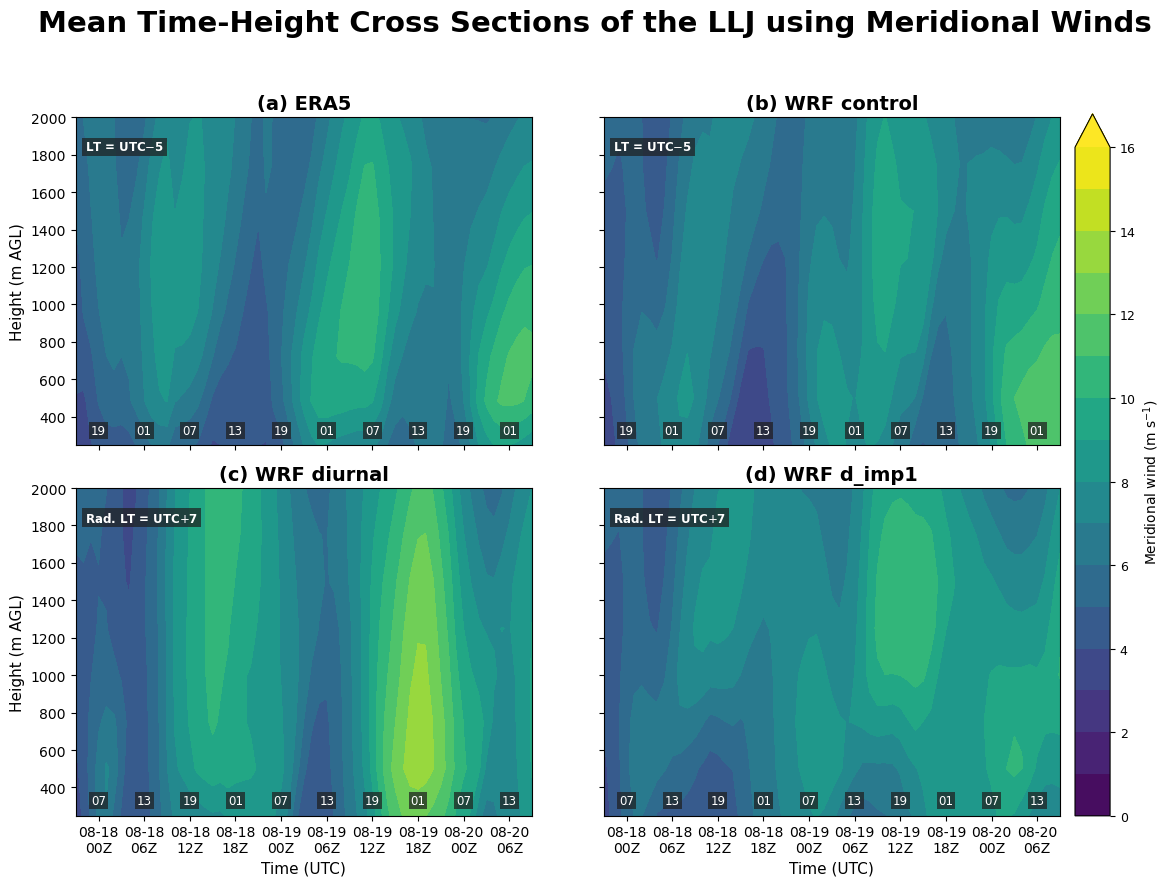

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.transforms as mtransforms

# --- Colors for wind ---
cmap_wind = plt.cm.plasma
levels_wind = np.linspace(0, 16, 17)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.15, hspace=0.25)

# Titles for the panels
titles = [
    "(a) ERA5",
    "(b) WRF control",
    "(c) WRF diurnal",
    "(d) WRF d_imp1"
]

# Put your time–height data into a list
datasets = [
    (time_dt64, height_per_level, v_mean),        # ERA5
    (times, heights, ctrlv_avg),                  # Control
    (times, heights, diurnalv_avg),               # Diurnal
    (times, heights, dimpv_avg)                   # d_imp1
]

# Local-time conventions:
# ERA5/control: LT = UTC - 5 h
# diurnal/d_imp1: radiative-clock LT = UTC + 7 h
lt_offsets = [-5, -5, 7, 7]
lt_names = [
    "LT = UTC$-$5",
    "LT = UTC$-$5",
    "Rad. LT = UTC$+$7",
    "Rad. LT = UTC$+$7"
]

# Loop over axes
for ax, (t, h, vdata), title, lt_offset, lt_name in zip(
    axes.flat, datasets, titles, lt_offsets, lt_names
):
    # Convert time to Matplotlib date numbers
    t_num = mdates.date2num(t)

    cf = ax.contourf(
        t_num,
        h,
        vdata.T,
        levels=levels_wind,
        cmap="viridis",
        extend="max"
    )

    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylim(250, 2000)

    # Format x-axis as UTC dates
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%HZ"))

    # --------------------------------------------------
    # Add local-time labels without changing x-limits
    # --------------------------------------------------
    fig.canvas.draw()
    xticks = ax.get_xticks()

    xmin = np.nanmin(t_num)
    xmax = np.nanmax(t_num)
    pad = 0.025 * (xmax - xmin)

    # Avoid labeling ticks at the exact edges
    xticks_use = xticks[(xticks >= xmin + pad) & (xticks <= xmax - pad)]

    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

    # LT convention label in upper-left corner, away from hour labels
    ax.text(
        0.02,
        0.93,
        lt_name,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8.5,
        fontweight="bold",
        color="white",
        bbox=dict(
            facecolor="0.12",
            alpha=0.72,
            edgecolor="none",
            pad=1.8
        ),
        zorder=10
    )

    # LT hour labels along bottom inside each panel
    for x in xticks_use:
        dt = mdates.num2date(x).replace(tzinfo=None)
        lt_hour = (dt.hour + lt_offset) % 24

        ax.text(
            x,
            0.025,
            f"{lt_hour:02d}",
            transform=trans,
            ha="center",
            va="bottom",
            fontsize=8.5,
            color="white",
            bbox=dict(
                facecolor="0.12",
                alpha=0.72,
                edgecolor="none",
                pad=1.4
            ),
            zorder=10
        )

# Label only bottom row with Time
for ax in axes[1, :]:
    ax.set_xlabel("Time (UTC)", fontsize=11)

# Label only left column with Height
for ax in axes[:, 0]:
    ax.set_ylabel("Height (m AGL)", fontsize=11)

# Shared colorbar
cbar = fig.colorbar(
    cf,
    ax=axes,
    orientation="vertical",
    fraction=0.05,
    pad=0.5,
    extend="max"
)
cbar.set_label("Meridional wind (m s$^{-1}$)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# Manually adjust the colorbar position
cbar.ax.set_position([0.90, 0.0835, 0.04, 0.78])

# Overall title
fig.suptitle(
    "Mean Time-Height Cross Sections of the LLJ using Meridional Winds",
    fontsize=21,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.savefig("LLJ_timeheight.png", dpi=600, bbox_inches="tight")
plt.show()